# VMC Finger Stiffness Model — Supplementary Validation

Validates the three VMC stiffness formulations for a single finger:
- **Finger-space** (`stiffness2fingerspace`): virtual springs in joint-angle coordinates
- **Task-space** (`stiffness2taskspace`): virtual springs in Cartesian coordinates
- **Mixed-space** (`stiffness2mixedspace`): both simultaneously

Experiments run for each model:
1. Finite-difference stiffness validation (1st-order Salisbury vs. 2nd-order CCT)
2. Stiffness gradient-descent convergence
3. Reference gradient-descent convergence
4. Stiffness inversion accuracy

In [11]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.insert(0, os.path.join('..'))
from plot_config import COLORS, FIG_W_SINGLE, FIG_W_DOUBLE, set_font_size

FONT_SIZE = 18
set_font_size(FONT_SIZE)
plt.rcParams['savefig.bbox'] = 'tight'
COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']

OUT_DIR = os.path.join('outputs', 'stiffness_model')
os.makedirs(OUT_DIR, exist_ok=True)

In [12]:
from StiffnessModelFinger.stiffness2fingerspace import tip_stiffness_FingerSpace
from StiffnessModelFinger.stiffness2taskspace   import tip_stiffness_TaskSpace
from StiffnessModelFinger.stiffness2mixedspace  import tip_stiffness_MixedSpace
from KinematicsFinger.FK_Finger import FK_DIP, FK_MCP, motor_to_joint

# Shared experiment parameters
Q_BASE        = np.array([30.0, 20.0])          # current motor angles [deg]
Q_REF         = np.array([50.0, 50.0])          # virtual reference [deg]
ETA           = np.array([0.8, 0.7])             # tendon efficiency
MAX_ITERS     = 10000
EPS_VALS      = [0.05, 0.005, 0.0005]           # perturbation sizes for FD validation
N_FD          = 6                               # random directions per eps

# Instantiate models
model_fs = tip_stiffness_FingerSpace(n=None, eta=ETA)
model_ts = tip_stiffness_TaskSpace(n=None, eta=np.diag(ETA))
model_ms = tip_stiffness_MixedSpace(n=None, eta=np.diag(ETA))

# --- finger-space: K and references ---
K_fs          = np.diag([0.5, 0.3, 0.2])
theta_ref_deg = np.degrees(motor_to_joint(np.radians(Q_REF)))

# --- task-space: K and d_ref ---
K_ts    = np.diag([1.0, 1.0, 1.0])
K_base  = np.diag([0.5, 0.5, 0.5])
d_ref_ts = {
    'tip':  FK_DIP(np.radians(Q_REF), model_ts.rtip),
    'base': FK_MCP(np.radians(Q_REF), model_ts.rbase),
}

# --- mixed-space: K and d_ref ---
K_theta_ms = np.diag([0.4, 0.3, 0.2])
K_tip_ms   = np.diag([1.0, 1.0, 1.0])
K_base_ms  = np.diag([0.5, 0.5, 0.5])
d_ref_ms   = {
    'tip':  FK_DIP(np.radians(Q_REF), model_ms.rtip),
    'base': FK_MCP(np.radians(Q_REF), model_ms.rbase),
}
theta_ref_ms = np.degrees(motor_to_joint(np.radians(Q_REF)))

print('Models instantiated.')

Models instantiated.


## 1 — Finite-Difference Stiffness Validation

Relative FD residual $\|K_x\,\Delta x + \Delta f\| / \|\Delta f\|$ as a function of
perturbation size $\epsilon$ (deg), averaged over 6 random motor-angle directions.
1st-order (Salisbury) should plateau; 2nd-order (CCT) should converge as $O(\epsilon)$.

In [13]:
np.random.seed(1)
fd_results = {}   # {model_name: {eps: (err1, err2)}}

# --- finger-space ---
f0_fs = model_fs.tip_force(Q_BASE, theta_ref_deg, K_fs)
K1_fs = model_fs.tip_stiffness(Q_BASE, K_fs, theta_ref_deg)
K2_fs = model_fs.tip_stiffness(Q_BASE, K_fs, theta_ref_deg, f_ext=f0_fs)
x0_fs = FK_DIP(np.radians(Q_BASE), model_fs.rtip)
fd_results['FingerSpace'] = {}
for eps in EPS_VALS:
    e1, e2 = [], []
    for _ in range(N_FD):
        dq = np.random.randn(2); dq *= eps / np.linalg.norm(dq)
        dx = FK_DIP(np.radians(Q_BASE + dq), model_fs.rtip) - x0_fs
        df = model_fs.tip_force(Q_BASE + dq, theta_ref_deg, K_fs) - f0_fs
        s  = np.linalg.norm(df) + 1e-15
        e1.append(np.linalg.norm(K1_fs @ dx + df) / s)
        e2.append(np.linalg.norm(K2_fs @ dx + df) / s)
    fd_results['FingerSpace'][eps] = (np.mean(e1), np.mean(e2))

# --- task-space ---
f0_ts = model_ts.tip_force(Q_BASE, d_ref_ts, K_ts, K_base)
K1_ts = model_ts.tip_stiffness(Q_BASE, K_ts, K_base)
K2_ts = model_ts.tip_stiffness(Q_BASE, K_ts, K_base, d_ref=d_ref_ts, f_ext=f0_ts)
x0_ts = FK_DIP(np.radians(Q_BASE), model_ts.rtip)
fd_results['TaskSpace'] = {}
for eps in EPS_VALS:
    e1, e2 = [], []
    for _ in range(N_FD):
        dq = np.random.randn(2); dq *= eps / np.linalg.norm(dq)
        dx = FK_DIP(np.radians(Q_BASE + dq), model_ts.rtip) - x0_ts
        df = model_ts.tip_force(Q_BASE + dq, d_ref_ts, K_ts, K_base) - f0_ts
        s  = np.linalg.norm(df) + 1e-15
        e1.append(np.linalg.norm(K1_ts @ dx + df) / s)
        e2.append(np.linalg.norm(K2_ts @ dx + df) / s)
    fd_results['TaskSpace'][eps] = (np.mean(e1), np.mean(e2))

# --- mixed-space ---
f0_ms = model_ms.tip_force(Q_BASE, theta_ref_ms, d_ref_ms, K_theta_ms, K_tip_ms, K_base_ms)
K1_ms = model_ms.tip_stiffness(Q_BASE, K_theta_ms, K_tip_ms, K_base_ms)
K2_ms = model_ms.tip_stiffness(Q_BASE, K_theta_ms, K_tip_ms, K_base_ms,
                                theta_ref_deg=theta_ref_ms, d_ref=d_ref_ms, f_ext=f0_ms)
x0_ms = FK_DIP(np.radians(Q_BASE), model_ms.rtip)
fd_results['MixedSpace'] = {}
for eps in EPS_VALS:
    e1, e2 = [], []
    for _ in range(N_FD):
        dq = np.random.randn(2); dq *= eps / np.linalg.norm(dq)
        dx = FK_DIP(np.radians(Q_BASE + dq), model_ms.rtip) - x0_ms
        df = model_ms.tip_force(Q_BASE + dq, theta_ref_ms, d_ref_ms,
                                K_theta_ms, K_tip_ms, K_base_ms) - f0_ms
        s  = np.linalg.norm(df) + 1e-15
        e1.append(np.linalg.norm(K1_ms @ dx + df) / s)
        e2.append(np.linalg.norm(K2_ms @ dx + df) / s)
    fd_results['MixedSpace'][eps] = (np.mean(e1), np.mean(e2))

print('FD validation done.')

FD validation done.


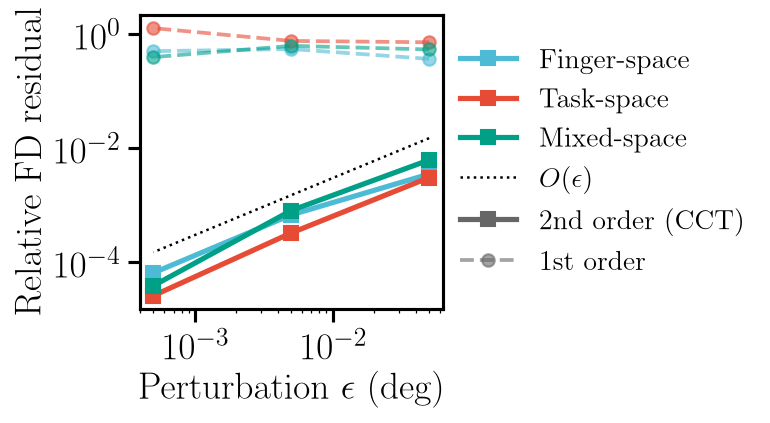

In [14]:
MODEL_NAMES = ['FingerSpace', 'TaskSpace', 'MixedSpace']
MODEL_LABELS = ['Finger-space', 'Task-space', 'Mixed-space']
MODEL_COLORS = [COLORS[0], COLORS[1], COLORS[2]]

# ---- size / aspect for THIS graph only ----
W_IN   = 8.5 * 0.65
ASPECT = 5.15 / 9
H_IN   = W_IN * ASPECT
fig, ax = plt.subplots(figsize=(W_IN, H_IN))

for name, label, color in zip(MODEL_NAMES, MODEL_LABELS, MODEL_COLORS):
    eps_arr = EPS_VALS
    err1 = [fd_results[name][e][0] for e in eps_arr]
    err2 = [fd_results[name][e][1] for e in eps_arr]
    ax.plot(eps_arr, err1, 'o--', color=color, lw=1.8, ms=6, alpha=0.6)
    ax.plot(eps_arr, err2, 's-',  color=color, lw=2.5, ms=7, label=label)

# Reference O(eps) slope
ax.plot(EPS_VALS, [0.3 * e / EPS_VALS[0] * EPS_VALS[0] for e in EPS_VALS],
        'k:', lw=1.2, label=r'$O(\epsilon)$')

# Legend handles: solid=2nd order, dashed=1st order
from matplotlib.lines import Line2D
_leg_extra = [
    Line2D([0],[0], color='0.4', ls='-',  lw=2.5, marker='s', ms=7,  label='2nd order (CCT)'),
    Line2D([0],[0], color='0.4', ls='--', lw=1.8, marker='o', ms=6, alpha=0.6, label='1st order'),
]
handles, labels = ax.get_legend_handles_labels()
# Legend outside the axes, on the right, vertically centered on the plot.
ax.legend(handles=handles + _leg_extra,
          labels=labels + ['2nd order (CCT)', '1st order'],
          fontsize=plt.rcParams['legend.fontsize'],
          loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'Perturbation $\epsilon$ (deg)')
ax.set_ylabel('Relative FD residual')
ax.xaxis.set_major_formatter(mticker.LogFormatterSciNotation())
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fd_stiffness_validation.pdf'))
plt.show()

## 2 — Stiffness Gradient-Descent Convergence

Force error $\|f_{\rm meas} - f_{\rm des}\|$ vs. iteration when optimising the virtual stiffness matrices $K$ to match a target tip force.

In [15]:
F_DES = np.array([0.0, 0.05, 0.03])
LOG_EVERY = 200

gd_stiff_history = {}

# --- finger-space ---
K_opt = np.diag([0.5, 0.3, 0.2]).copy()
hist = []
for i in range(MAX_ITERS):
    f_meas = model_fs.tip_force(Q_BASE, theta_ref_deg, K_opt)
    if i % LOG_EVERY == 0: hist.append((i, np.linalg.norm(f_meas - F_DES)))
    K_opt = model_fs.stiffness_descent(Q_BASE, theta_ref_deg, K_opt, f_meas, F_DES, lr=5e-4)
f_final = model_fs.tip_force(Q_BASE, theta_ref_deg, K_opt)
hist.append((MAX_ITERS, np.linalg.norm(f_final - F_DES)))
gd_stiff_history['FingerSpace'] = hist
print(f'FingerSpace stiffness_descent: final error = {hist[-1][1]:.6f}')

# --- task-space ---
K_ti_opt, K_ba_opt = np.diag([1.0, 1.0, 1.0]).copy(), np.diag([0.5, 0.5, 0.5]).copy()
hist = []
for i in range(MAX_ITERS):
    f_meas = model_ts.tip_force(Q_BASE, d_ref_ts, K_ti_opt, K_ba_opt)
    if i % LOG_EVERY == 0: hist.append((i, np.linalg.norm(f_meas - F_DES)))
    K_ti_opt, K_ba_opt = model_ts.stiffness_descent(
        Q_BASE, d_ref_ts, K_ti_opt, K_ba_opt, f_meas, F_DES, lr=50)
f_final = model_ts.tip_force(Q_BASE, d_ref_ts, K_ti_opt, K_ba_opt)
hist.append((MAX_ITERS, np.linalg.norm(f_final - F_DES)))
gd_stiff_history['TaskSpace'] = hist
print(f'TaskSpace stiffness_descent: final error = {hist[-1][1]:.6f}')

# --- mixed-space ---
K_th_opt = np.diag([0.4, 0.3, 0.2]).copy()
K_ti_opt = np.diag([1.0, 1.0, 1.0]).copy()
K_ba_opt = np.diag([0.5, 0.5, 0.5]).copy()
hist = []
for i in range(MAX_ITERS):
    f_meas = model_ms.tip_force(Q_BASE, theta_ref_ms, d_ref_ms, K_th_opt, K_ti_opt, K_ba_opt)
    if i % LOG_EVERY == 0: hist.append((i, np.linalg.norm(f_meas - F_DES)))
    K_th_opt, K_ti_opt, K_ba_opt = model_ms.stiffness_descent(
        Q_BASE, theta_ref_ms, d_ref_ms, K_th_opt, K_ti_opt, K_ba_opt,
        f_meas, F_DES, lr=(5e-4, 5e-4, 5e-4))
f_final = model_ms.tip_force(Q_BASE, theta_ref_ms, d_ref_ms, K_th_opt, K_ti_opt, K_ba_opt)
hist.append((MAX_ITERS, np.linalg.norm(f_final - F_DES)))
gd_stiff_history['MixedSpace'] = hist
print(f'MixedSpace stiffness_descent: final error = {hist[-1][1]:.6f}')

FingerSpace stiffness_descent: final error = 0.000000
TaskSpace stiffness_descent: final error = 0.000000
MixedSpace stiffness_descent: final error = 0.000000


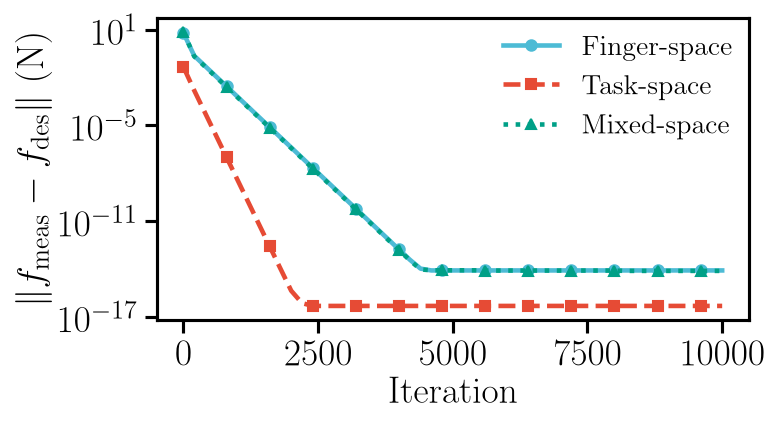

In [16]:
# ---- size / aspect for THIS graph only ----
W_IN   = 8.5 * 0.65
ASPECT = 5.15 / 9
H_IN   = W_IN * ASPECT
fig, ax = plt.subplots(figsize=(W_IN, H_IN))

# Distinct linestyle + marker per model so overlapping curves (e.g. FingerSpace
# and MixedSpace, which track each other almost exactly at this pose) stay
# visually distinguishable even where color alone can't separate them.
LINESTYLES = ['-', '--', ':']
MARKERS    = ['o', 's', '^']

for name, label, color, ls, mk in zip(MODEL_NAMES, MODEL_LABELS, MODEL_COLORS, LINESTYLES, MARKERS):
    hist = gd_stiff_history[name]
    iters, errs = zip(*hist)
    ax.semilogy(iters, errs, ls, color=color, lw=2.2, marker=mk,
                markevery=4, markersize=5, label=label)

ax.set_xlabel('Iteration')
ax.set_ylabel(r'$\|f_{\rm meas} - f_{\rm des}\|$ (N)')
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'stiffness_descent_convergence.pdf'))
plt.show()

## 3 — Reference Gradient-Descent Convergence

Force error $\|f_{\rm meas} - f_{\rm des}\|$ vs. iteration when optimising the virtual reference $\theta_{\rm ref}$ (and $d_{\rm ref}$ for task-space models).

In [17]:
F_DES_REF = np.array([0.0, 0.05, 0.03])

gd_ref_history = {}

# --- finger-space ---
theta_opt = np.degrees(motor_to_joint(np.radians(Q_REF))).copy()
hist = []
for i in range(MAX_ITERS):
    f_meas = model_fs.tip_force(Q_BASE, theta_opt, K_fs)
    if i % LOG_EVERY == 0: hist.append((i, np.linalg.norm(f_meas - F_DES_REF)))
    theta_opt = model_fs.ref_descent(Q_BASE, K_fs, theta_opt, f_meas, F_DES_REF, lr=1e-3)
f_final = model_fs.tip_force(Q_BASE, theta_opt, K_fs)
hist.append((MAX_ITERS, np.linalg.norm(f_final - F_DES_REF)))
gd_ref_history['FingerSpace'] = hist
print(f'FingerSpace ref_descent: final error = {hist[-1][1]:.6f}')

# --- task-space ---
d_ref_opt = {'tip':  d_ref_ts['tip'].copy(), 'base': d_ref_ts['base'].copy()}
hist = []
for i in range(MAX_ITERS):
    f_meas = model_ts.tip_force(Q_BASE, d_ref_opt, K_ts, K_base)
    if i % LOG_EVERY == 0: hist.append((i, np.linalg.norm(f_meas - F_DES_REF)))
    d_ref_opt = model_ts.ref_descent(Q_BASE, d_ref_opt, K_ts, K_base, f_meas, F_DES_REF, lr=0.5)
f_final = model_ts.tip_force(Q_BASE, d_ref_opt, K_ts, K_base)
hist.append((MAX_ITERS, np.linalg.norm(f_final - F_DES_REF)))
gd_ref_history['TaskSpace'] = hist
print(f'TaskSpace ref_descent: final error = {hist[-1][1]:.6f}')

# --- mixed-space ---
theta_ref_opt_ms = np.degrees(motor_to_joint(np.radians(Q_REF))).copy()
d_ref_opt_ms = {'tip':  d_ref_ms['tip'].copy(), 'base': d_ref_ms['base'].copy()}
hist = []
for i in range(MAX_ITERS):
    f_meas = model_ms.tip_force(Q_BASE, theta_ref_opt_ms, d_ref_opt_ms,
                                K_theta_ms, K_tip_ms, K_base_ms)
    if i % LOG_EVERY == 0: hist.append((i, np.linalg.norm(f_meas - F_DES_REF)))
    theta_ref_opt_ms, d_ref_opt_ms = model_ms.ref_descent(
        Q_BASE, theta_ref_opt_ms, d_ref_opt_ms,
        K_theta_ms, K_tip_ms, K_base_ms,
        f_meas, F_DES_REF, lr=(5e-05, 1e-02))
f_final = model_ms.tip_force(Q_BASE, theta_ref_opt_ms, d_ref_opt_ms,
                              K_theta_ms, K_tip_ms, K_base_ms)
hist.append((MAX_ITERS, np.linalg.norm(f_final - F_DES_REF)))
gd_ref_history['MixedSpace'] = hist
print(f'MixedSpace ref_descent: final error = {hist[-1][1]:.6f}')

FingerSpace ref_descent: final error = 0.000000
TaskSpace ref_descent: final error = 0.000000
MixedSpace ref_descent: final error = 0.000000


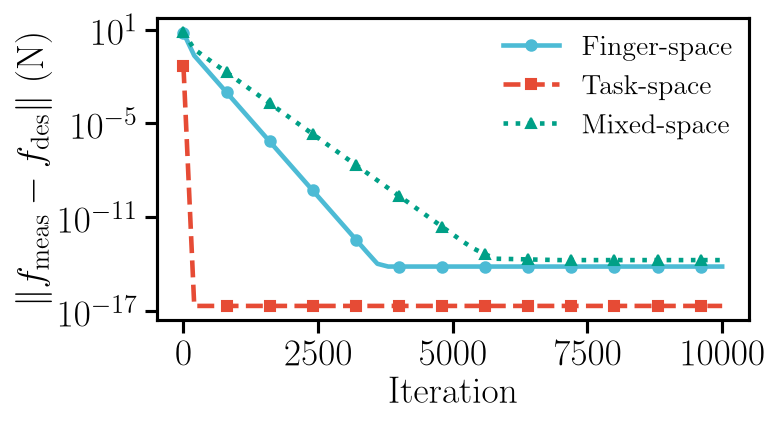

In [18]:
# ---- size / aspect for THIS graph only ----
W_IN   = 8.5 * 0.65
ASPECT = 5.15 / 9
H_IN   = W_IN * ASPECT
fig, ax = plt.subplots(figsize=(W_IN, H_IN))

# Distinct linestyle + marker per model -- FingerSpace and MixedSpace converge
# to nearly the same floor here too, same as the stiffness_descent plot.
LINESTYLES = ['-', '--', ':']
MARKERS    = ['o', 's', '^']

for name, label, color, ls, mk in zip(MODEL_NAMES, MODEL_LABELS, MODEL_COLORS, LINESTYLES, MARKERS):
    hist = gd_ref_history[name]
    iters, errs = zip(*hist)
    ax.semilogy(iters, errs, ls, color=color, lw=2.2, marker=mk,
                markevery=4, markersize=5, label=label)

ax.set_xlabel('Iteration')
ax.set_ylabel(r'$\|f_{\rm meas} - f_{\rm des}\|$ (N)')
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'ref_descent_convergence.pdf'))
plt.show()

## 4 — Stiffness Inversion Accuracy

Frobenius-norm reconstruction error $\|K_{\rm recon} - K_{\rm des}\|_F$ from the minimum-norm pseudo-inverse of the stiffness map.

In [19]:
# --- finger-space ---
K_target_fs = np.diag([0.8, 0.4, 0.25])
K_des_fs    = model_fs.tip_stiffness(Q_BASE, K_target_fs)
K_ff_fs     = model_fs.stiffness_inversion(Q_BASE, K_des_fs)
K_rec_fs    = model_fs.tip_stiffness(Q_BASE, K_ff_fs)
err_fs      = np.linalg.norm(K_rec_fs - K_des_fs, 'fro')
print(f'FingerSpace inversion: ||K_recon - K_des||_F = {err_fs:.2e}')

# --- task-space ---
K_target_ts  = np.diag([1.5, 1.5, 1.5])
K_target_base = np.diag([0.8, 0.8, 0.8])
K_des_ts    = model_ts.tip_stiffness(Q_BASE, K_target_ts, K_target_base)
K_ff_tip_ts, K_ff_base_ts = model_ts.stiffness_inversion(Q_BASE, K_des_ts)
K_rec_ts    = model_ts.tip_stiffness(Q_BASE, K_ff_tip_ts, K_ff_base_ts)
err_ts      = np.linalg.norm(K_rec_ts - K_des_ts, 'fro')
print(f'TaskSpace inversion:   ||K_recon - K_des||_F = {err_ts:.2e}')

# --- mixed-space ---
K_des_ms = model_ms.tip_stiffness(Q_BASE,
               np.diag([0.6, 0.4, 0.3]), np.diag([1.5, 1.5, 1.5]), np.diag([0.8, 0.8, 0.8]))
K_ff_th, K_ff_ti, K_ff_ba = model_ms.stiffness_inversion(Q_BASE, K_des_ms)
K_rec_ms = model_ms.tip_stiffness(Q_BASE, K_ff_th, K_ff_ti, K_ff_ba)
err_ms   = np.linalg.norm(K_rec_ms - K_des_ms, 'fro')
print(f'MixedSpace inversion:  ||K_recon - K_des||_F = {err_ms:.2e}')

FingerSpace inversion: ||K_recon - K_des||_F = 7.68e-12
TaskSpace inversion:   ||K_recon - K_des||_F = 4.68e-15
MixedSpace inversion:  ||K_recon - K_des||_F = 1.81e-11


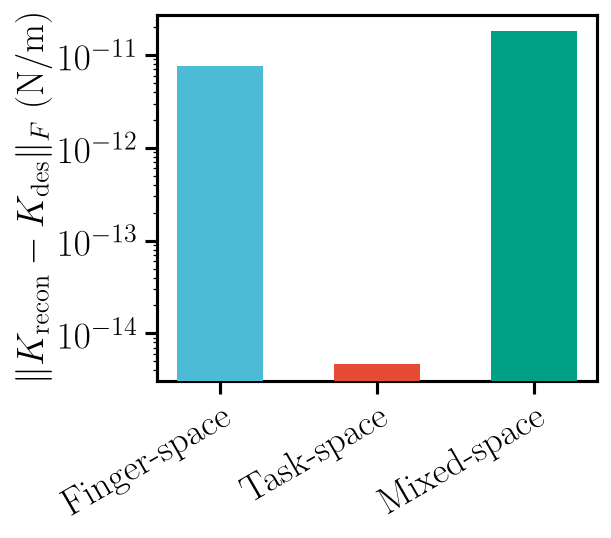

In [20]:
# ---- size / aspect for THIS graph only ----
W_IN   = 8.5 * 0.52
ASPECT = 8 / 9
H_IN   = W_IN * ASPECT
fig, ax = plt.subplots(figsize=(W_IN, H_IN))

errs   = [err_fs, err_ts, err_ms]
x_pos  = np.arange(len(MODEL_LABELS))
bars = ax.bar(x_pos, errs, color=MODEL_COLORS[:3], width=0.55, zorder=3)
ax.set_xticks(x_pos)
# Rotated -- the three labels collide when written horizontally at this width.
ax.set_xticklabels(MODEL_LABELS, rotation=30, ha='right', rotation_mode='anchor')
ax.set_ylabel(r'$\|K_{\rm recon} - K_{\rm des}\|_F$ (N/m)')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.LogFormatterSciNotation())
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'stiffness_inversion_accuracy.pdf'))
plt.show()